# Proyecto PlusTI

- Andre Jo
- Pedro Guzmán
- Javier Chen

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt

In [3]:
bolivia_df = pd.read_csv('./data/Copia de 01_bo_vip_seed22_n100000.csv', sep = ';')
brasil_df = pd.read_csv('./data/Copia de 02_br_privado_seed33_n100000.csv', sep = ';')
df_guatemala = pd.read_csv('./data/Copia de 03_gt_estatal_seed3_n100000.csv', sep = ';')

Seleccionamos el dataset de Bolivia

In [4]:
bolivia_df.head()

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,...,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,...,500.12,True,8717.0,20,Tue,True,Approved,2012.51,TARIJA,False
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,...,1898.93,False,4.9,20,Tue,True,Approved,1096.46,LAPAZ,False
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,...,349.85,False,4.4,20,Tue,True,Approved,1528.37,SANTACRUZ,False
3,3a836c25-7a8c-473b-8141-3e84ba3f212d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002587,PLATINUM,ATM,VISA,479500******0288,...,345.58,True,3966.0,20,Tue,True,Approved,2483.34,SUCRE,False
4,be9956da-924f-4c68-aed8-f0c5d949e577,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000087,PRIVATE,POS,VISA,479500******0249,...,118.90,False,348.0,20,Tue,True,NaN,1334.55,SUCRE,False


Ahora, vemos la dimensión del dataset

In [20]:
bolivia_df.shape

(100003, 66)

Ahora, analizaremos cuántas transacciones son fraude

In [21]:
bolivia_df['is_fraud'].value_counts()

is_fraud
False    95084
True      4919
Name: count, dtype: int64

La mayor parte de las transacciones no son fraudes, debemos balancear el dataset pero antes debemos comprender la estructura de los datos

Primero, vamos a determinar si las columnas tienen un tipo de dato que es coherente con la naturaleza de la variable. 

In [5]:
bolivia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100003 entries, 0 to 100002
Data columns (total 66 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100003 non-null  str    
 1   bank_code                         100003 non-null  str    
 2   bank_name                         100003 non-null  str    
 3   bank_country                      100003 non-null  str    
 4   bank_tier                         100003 non-null  str    
 5   client_id                         100003 non-null  str    
 6   client_segment                    98957 non-null   str    
 7   channel                           100003 non-null  str    
 8   card_brand                        98961 non-null   str    
 9   pan_masked                        100003 non-null  str    
 10  pan_hash                          100003 non-null  str    
 11  MTI                               100003 non-null  int64  
 12 

Hay variables numéricas que en realidad corresponden más a una variable categórica, por ejemplo la DE3, la cuál solo corresponde a un código de identificación de la transaccón. Sin embargo, según la documentación oficial del modelo LightGBM (el que se usará para entrenar los modelos), este funciona de forma correcta con variables categoricas codificadas como int. Por lo tanto, vamos a dejar dichas variables sin alterar su tipo de datos.

Ahora vamos a hacer un análisis de las variables numéricas, luego de las categoricas.

Las variables que realmente son numéricas en este dataset son:

- DE4_amount_transaction
- DE6_amount_cardholder_billing
- amount_local
- amount_tx_currency
- amount_usd
- DE9_conversion_rate_billing
- client_baseline_amount

vamos a dejar la variable objetivo para análisis de correlación

In [25]:
numeric = [
    "DE4_amount_transaction",
    "DE6_amount_cardholder_billing",
    "amount_local",
    "amount_tx_currency",
    "amount_usd",
    "DE9_conversion_rate_billing",
    "client_baseline_amount",
    "is_fraud"
]

bolivia_numeric = bolivia_df[numeric]

Primero, obtenemos un resumen inicial de estas variables

In [26]:
bolivia_numeric.describe()

,DE4_amount_transaction,DE6_amount_cardholder_billing,amount_local,amount_tx_currency,amount_usd,DE9_conversion_rate_billing,client_baseline_amount
count,1.000030e+05,1.000030e+05,100003.000000,1.000030e+05,100003.000000,9.900200e+04,100003.000000
mean,1.426779e+06,2.971216e+05,2971.215672,1.426779e+04,430.610978,2.162929e+07,1567.096206
std,1.154981e+07,4.125483e+05,4125.482670,1.154981e+05,597.896042,2.567151e+07,545.769782
min,7.000000e+00,5.000000e+01,0.500000,7.000000e-02,0.070000,7.262900e+04,600.000000
25%,3.704750e+04,5.813150e+04,581.315000,3.704750e+02,84.250000,1.000000e+07,1097.220000
50%,1.112500e+05,1.382990e+05,1382.990000,1.112500e+03,200.430000,1.000000e+07,1568.340000
75%,3.013400e+05,3.339170e+05,3339.170000,3.013400e+03,483.935000,1.000000e+07,2037.420000
max,4.911819e+08,4.645012e+06,46450.120000,4.911819e+06,6731.900000,8.935550e+07,2498.920000


Con este resumen nos damos cuenta de que existen valores atípicos en casi todas las variables, pues vemos una amplia diferencia entre los valores máximos y mínimos. 

Ahora verificamos si hay NA's

In [27]:
bolivia_numeric.isna().sum()

DE4_amount_transaction              0
DE6_amount_cardholder_billing       0
amount_local                        0
amount_tx_currency                  0
amount_usd                          0
DE9_conversion_rate_billing      1001
client_baseline_amount              0
is_fraud                            0
dtype: int64

Solamente la variable DE9 tiene algunos campos faltantes y representan el 1% de los valores totales, podemos sutituirlos con la mediana. 

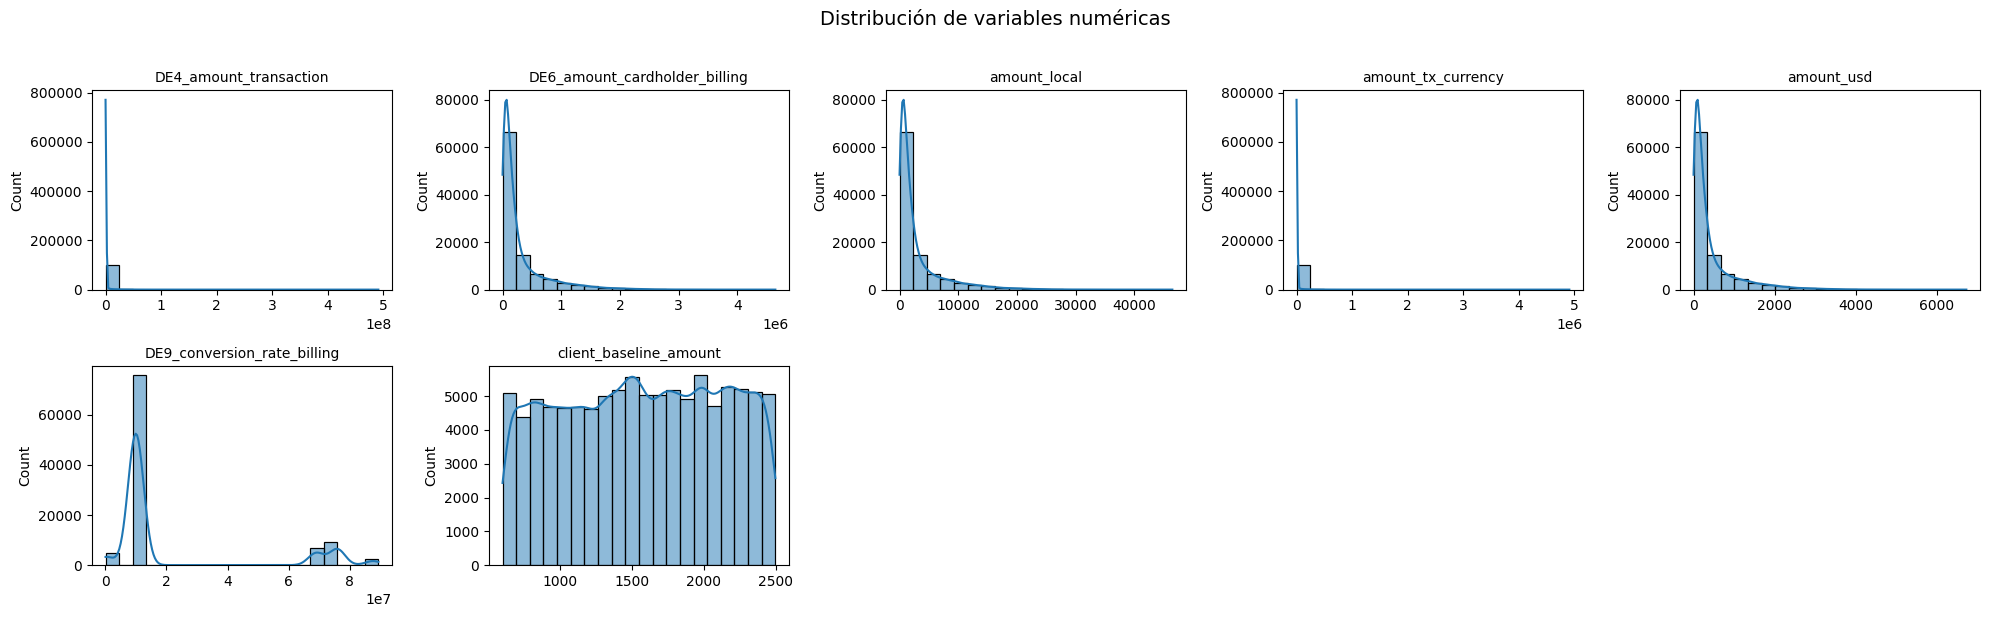

In [19]:
cols = numeric
n_cols = 5
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(bolivia_df[col].dropna(), kde=True, ax=axes[i], bins=20)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de variables numéricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Ninguna variable tiene una distribución normal 